URL index: [Home](https://zzz.bwh.harvard.edu/luna-walkthrough/) | [Data](https://zzz.bwh.harvard.edu/luna-walkthrough/data/) | [S1. File QC](https://zzz.bwh.harvard.edu/luna-walkthrough/p1/) | [S2. Signal QC](https://zzz.bwh.harvard.edu/luna-walkthrough/p2) | [S3. Staging](https://zzz.bwh.harvard.edu/luna-walkthrough/p3) | [S4. Artifacts](https://zzz.bwh.harvard.edu/luna-walkthrough/p4) | [S5. Analysis](https://zzz.bwh.harvard.edu/luna-walkthrough/p5)

Notebook index: [Index](../00_index.ipynb) | [S1. File QC](../p1/00_index.ipynb) | [S2. Signal QC](../p2/00_index.ipynb) | [S3. Staging](../p3/00_index.ipynb) | [S4. Artifacts](../p4/00_index.ipynb) | [S5. Analysis](../p5/00_index.ipynb)

---

# 2.4. EEG polarity checks

Walkthrough URL = [https://zzz.bwh.harvard.edu/luna-walkthrough/p2/pol/](https://zzz.bwh.harvard.edu/luna-walkthrough/p2/pol/)

In [2]:
import lunapi as lp
proj = lp.proj()
proj.sample_list( '../harm1.lst' )

initiated lunapi v1.2.3 <lunapi.lunapi0.luna object at 0x103f37eb0> 

read 20 individuals from ../harm1.lst


See the [original page](https://zzz.bwh.harvard.edu/luna-walkthrough/p2/pol/) for background on the EEG polarity checks.  We'll just step through the basics here.

---

To speed up this demonstration, here we restrict analyses to two channels only, C3 and C4. This is the Luna script (that will take a minute or two to run) we'll use that supports all three approaches above, here constrained to just the two signals (set via the variable `${s}`):

In [5]:
# luna harm1.lst  s=C3,C4 -o out.db \
# -s ' MASK ifnot=N2,N3
#      RE
#      FILTER sig=${s} bandpass=0.3,18 tw=1 ripple=0.02
#      CHEP-MASK sig=${s} ep-th=3
#      CHEP sig=${s} epochs
#      RE
#      POL sig=${s}
#      SPINDLES sig=${s} fc=15 so mag=2 all-spindles ignore-neg-peak nreps=1000 '

proj.var( 's' , 'C3,C4' ) 

res = proj.silent_proc( '''
       MASK ifnot=N2,N3
       RE
       FILTER sig=${s} bandpass=0.3,18 tw=1 ripple=0.02
       CHEP-MASK sig=${s} ep-th=3
       CHEP sig=${s} epochs
       RE
       POL sig=${s}
       SPINDLES sig=${s} fc=15 so mag=2 all-spindles ignore-neg-peak nreps=1000 ''' )


We'll extract the three tables: based on 1) spectral content, 2) SO morphology, and 3) spindle/SO phase coupling angle:

In [30]:
# destrat out.db +POL -r CH -v T_DIFF T_H1 > tmp/pol.1
p1 = proj.table( 'POL' , 'CH' )[[ 'ID' , 'CH', 'T_DIFF' , 'T_H1' ]].sort_values( [ 'ID' , 'CH' ] )  

# destrat out.db +SPINDLES -r CH -v SO_DUR SO_DUR_POS SO_DUR_NEG > tmp/pol.2
p2 = proj.table( 'SPINDLES' , 'CH' )[[ 'ID' , 'CH', 'SO_DUR', 'SO_DUR_POS' , 'SO_DUR_NEG' ]].sort_values( [ 'ID' , 'CH' ] )  

# destrat out.db +SPINDLES -r F CH -v COUPL_ANGLE  > tmp/pol.3
p3 = proj.table( 'SPINDLES' , 'CH_F' )[[ 'ID' , 'CH', 'F', 'COUPL_ANGLE' ]].sort_values( [ 'ID' , 'CH' ] )  

We'll create the three values from each approach:

In [31]:
p1

,ID,CH,T_DIFF,T_H1
0,F01,C3,-6.307524,-11.14914
20,F01,C4,-7.569134,-11.679272
1,F02,C3,-17.418843,-16.110408
21,F02,C4,-16.268477,-18.103541
2,F03,C3,-5.860964,-9.482419
22,F03,C4,-7.003196,-3.945015
3,F04,C3,-0.043598,0.38278
23,F04,C4,-2.169242,-0.080567
4,F05,C3,-24.217886,-26.505545
24,F05,C4,-24.94784,-27.894056


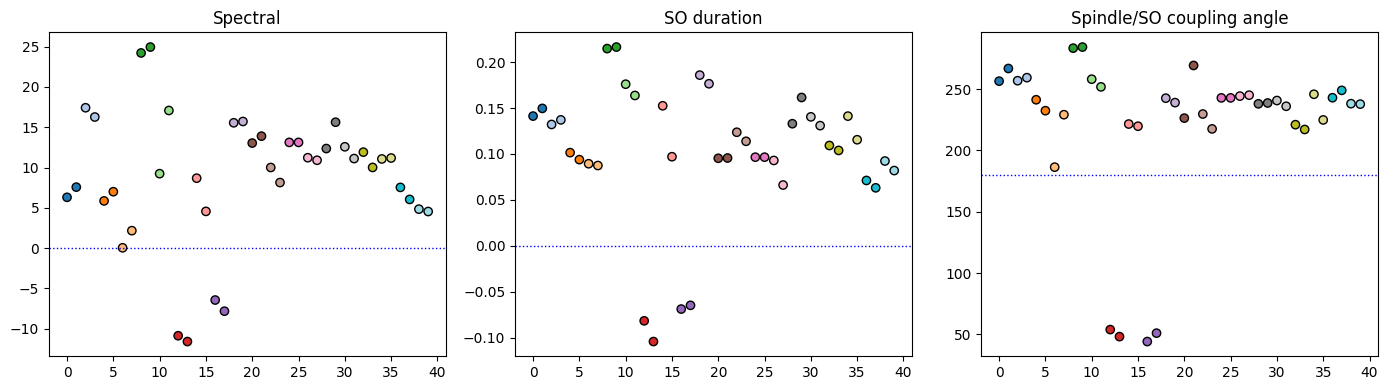

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x1 = -1 * pd.to_numeric( p1.T_DIFF ) 
x2 = np.log2( pd.to_numeric( p2.SO_DUR_POS ) / pd.to_numeric( p2.SO_DUR_NEG )  ) 
x3 = pd.to_numeric( p3.COUPL_ANGLE ) 

xi = np.arange(40)
cmap = plt.get_cmap('tab20')
base_colors = [cmap(i) for i in range(20)]
palette = [color for color in base_colors for _ in range(2)]

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(14, 4), sharex=True, sharey = False )

axes[0].scatter(xi, x1 , color=palette , edgecolor='black')
axes[1].scatter(xi, x2 , color=palette , edgecolor='black')
axes[2].scatter(xi, x3 , color=palette , edgecolor='black')

axes[0].axhline(y=0, color='blue', linestyle=':', linewidth=1)
axes[1].axhline(y=0, color='blue', linestyle=':', linewidth=1)
axes[2].axhline(y=180, color='blue', linestyle=':', linewidth=1)

axes[0].set_title('Spectral')
axes[1].set_title('SO duration')
axes[2].set_title('Spindle/SO coupling angle')

plt.tight_layout()
plt.show()

The red and purple points (`F07` and `F09`) are the two individuals with known reversed polarities.

---

Next, we've move on to making the [revised project](05_revised.ipynb). 